# IntelliPulse V5 — XGBoost Threshold Optimization

---

## 1 · V5 Objective

We investigate whether the tuned XGBoost model's performance can be improved by selecting an appropriate **classification threshold** instead of automatically using the default 0.50 cutoff.

In V4, the tuned XGBoost model achieved:
- **ROC-AUC** = 84.90%
- **F1** = 58.73% (@ 0.50)
- **Recall** = 52.14%
- **Precision** = 67.24%

**The central question:**
*"Does XGBoost have useful ranking capability that is not fully reflected when using the default 0.50 classification threshold?"*

### Experimental Rules
- We **do not** retrain XGBoost on the final train set (we use the saved V4 tuned model).
- We **do not** tune XGBoost hyperparameters again.
- The train/test split and preprocessing remain strictly identical.
- The **test set** must remain completely untouched during threshold optimization.
- The optimal threshold must be selected using validation predictions generated via cross-validation (out-of-fold probabilities) on the training data.

---

## 2 · Imports and Data Setup

In [1]:
import os
import json
from pathlib import Path
import copy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

# ── Configuration ────────────────────────────────────────────────────
RANDOM_STATE = 42

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

PROJECT_ROOT = Path.cwd().parent
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
MODEL_DIR = PROJECT_ROOT / "artifacts" / "models"
METRICS_DIR = PROJECT_ROOT / "artifacts" / "metrics"

print(f"Project root : {PROJECT_ROOT}")
print(f"Random state : {RANDOM_STATE}")

Project root : /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse
Random state : 42


In [2]:
# ── Load raw data ─────────────────────────────────────────────────────
assert RAW_DATA_PATH.exists(), f"Dataset not found at {RAW_DATA_PATH}"
df = pd.read_csv(RAW_DATA_PATH)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0.0)

ID_COL = "customerID"
TARGET_COL = "Churn"

X = df.drop(columns=[ID_COL, TARGET_COL])
y = df[TARGET_COL].map({"No": 0, "Yes": 1}).astype(int)

# ── Train/Test Split (Identical to V1-V4) ─────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Training set : {X_train.shape[0]:,} rows")
print(f"Test set     : {X_test.shape[0]:,} rows")

Training set : 5,634 rows
Test set     : 1,409 rows


In [3]:
# ── Load prior metrics ─────────────────────────────────────────────────
with open(METRICS_DIR / "baseline_v1.json") as f:
    v1_metrics = json.load(f)

with open(METRICS_DIR / "threshold_analysis_v2_1.json") as f:
    v2_1_data = json.load(f)
    v2_1_metrics = v2_1_data["provisional_metrics"]
    v2_1_threshold = v2_1_data.get("provisional_threshold", 0.27)

with open(METRICS_DIR / "random_forest_v3.json") as f:
    v3_metrics = json.load(f)["metrics_at_050"]

with open(METRICS_DIR / "random_forest_v3_1.json") as f:
    v3_1_metrics = json.load(f)["metrics_at_050"]

with open(METRICS_DIR / "xgboost_v4.json") as f:
    v4_data = json.load(f)
    v4_metrics = v4_data["metrics_at_050"]
    v4_best_params = v4_data["best_params"]

print("Prior metrics loaded.")

Prior metrics loaded.


---

## 3 · Generate Validation Probabilities (Out-of-Fold)

To tune the threshold without looking at the test set, we generate **out-of-fold probabilities** (`oof_proba_v5`) on the training set. 

For each of the $K=5$ folds:
1. The tuned V4 XGBoost model is trained on $K-1$ folds.
2. It predicts probabilities on the $1$ held-out fold.

This guarantees that every training observation gets exactly one predicted probability from a model that was **never trained on it**. This accurately simulates test-set performance.

In [4]:
# Load the already tuned V4 model
v4_model_path = MODEL_DIR / "churn_xgboost_v4_tuned.joblib"
model_v4_tuned = joblib.load(v4_model_path)

# Verify it produces probabilities
sample = X_test.iloc[:2]
sample_prob = model_v4_tuned.predict_proba(sample)
print(f"✓ Model loaded. sample predict_proba output shape: {sample_prob.shape}")

✓ Model loaded. sample predict_proba output shape: (2, 2)


In [5]:
# ── Generate Out-of-Fold (OOF) Probabilities ─────────────────────────
# We use cross_val_predict to handle the K-Fold process automatically
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Generating OOF probabilities using 5-fold cross-validation on X_train...")
oof_proba_v5 = cross_val_predict(
    estimator=model_v4_tuned,
    X=X_train,
    y=y_train,
    cv=cv_strategy,
    method="predict_proba",
    n_jobs=-1
)[:, 1]  # Get probability of class 1 (Churn)

print(f"✓ OOF probabilities generated for {len(oof_proba_v5)} training samples.")

Generating OOF probabilities using 5-fold cross-validation on X_train...


✓ OOF probabilities generated for 5634 training samples.


---

## 4 · Test Thresholds

We evaluate classification thresholds from 0.10 to 0.90 in increments of 0.01 using the OOF probabilities against `y_train`.

In [6]:
thresholds = np.arange(0.10, 0.91, 0.01)

records = []
for t in thresholds:
    # Apply threshold to OOF probabilities
    y_pred_t = (oof_proba_v5 >= t).astype(int)
    
    cm_t = confusion_matrix(y_train, y_pred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    
    records.append({
        "threshold": round(t, 2),
        "accuracy": accuracy_score(y_train, y_pred_t),
        "precision": precision_score(y_train, y_pred_t, zero_division=0),
        "recall": recall_score(y_train, y_pred_t, zero_division=0),
        "f1": f1_score(y_train, y_pred_t, zero_division=0),
        "tp": int(tp_t), "fp": int(fp_t),
        "fn": int(fn_t), "tn": int(tn_t),
    })

threshold_results_v5 = pd.DataFrame(records)

# Display top 10 by F1 (descending)
top_10_thresholds = threshold_results_v5.sort_values("f1", ascending=False).head(10)

print("Top 10 Thresholds (Validation Set OOF)")
print("=" * 80)
print(top_10_thresholds.to_string(index=False))

Top 10 Thresholds (Validation Set OOF)
 threshold  accuracy  precision   recall       f1   tp   fp  fn   tn
      0.29  0.767128   0.542857 0.775251 0.638567 1159  976 336 3163
      0.30  0.770146   0.547985 0.763880 0.638167 1142  942 353 3197
      0.31  0.772808   0.552878 0.751839 0.637188 1124  909 371 3230
      0.28  0.761981   0.535064 0.785953 0.636684 1175 1021 320 3118
      0.27  0.757898   0.529150 0.795318 0.635489 1189 1058 306 3081
      0.32  0.775293   0.558033 0.736455 0.634948 1101  872 394 3267
      0.26  0.753461   0.523043 0.804682 0.633992 1203 1097 292 3042
      0.25  0.749024   0.517168 0.816054 0.633108 1220 1139 275 3000
      0.38  0.795172   0.603522 0.664883 0.632718  994  653 501 3486
      0.34  0.780618   0.569288 0.711706 0.632580 1064  805 431 3334


---

## 5 · Select Optimal Threshold

We select the threshold with the highest validation F1. If multiple thresholds share the exact highest F1, we prefer the one with higher recall (lower threshold) because catching churners is critical for the business.

In [7]:
# Find highest F1
max_f1 = threshold_results_v5["f1"].max()

# Filter candidates with max F1
best_candidates = threshold_results_v5[threshold_results_v5["f1"] == max_f1]

# If tie, pick the one with lowest threshold (highest recall)
best_threshold_row = best_candidates.sort_values("threshold", ascending=True).iloc[0]
best_threshold_v5 = best_threshold_row["threshold"]
val_f1_at_best = best_threshold_row["f1"]

print("=" * 50)
print(f"  Best Threshold Selected : {best_threshold_v5:.2f}")
print(f"  Validation F1 at Best   : {val_f1_at_best:.4f}")
print("=" * 50)

  Best Threshold Selected : 0.29
  Validation F1 at Best   : 0.6386


---

## 6 · Visualization

We visualize the precision/recall trade-off across the threshold sweep.

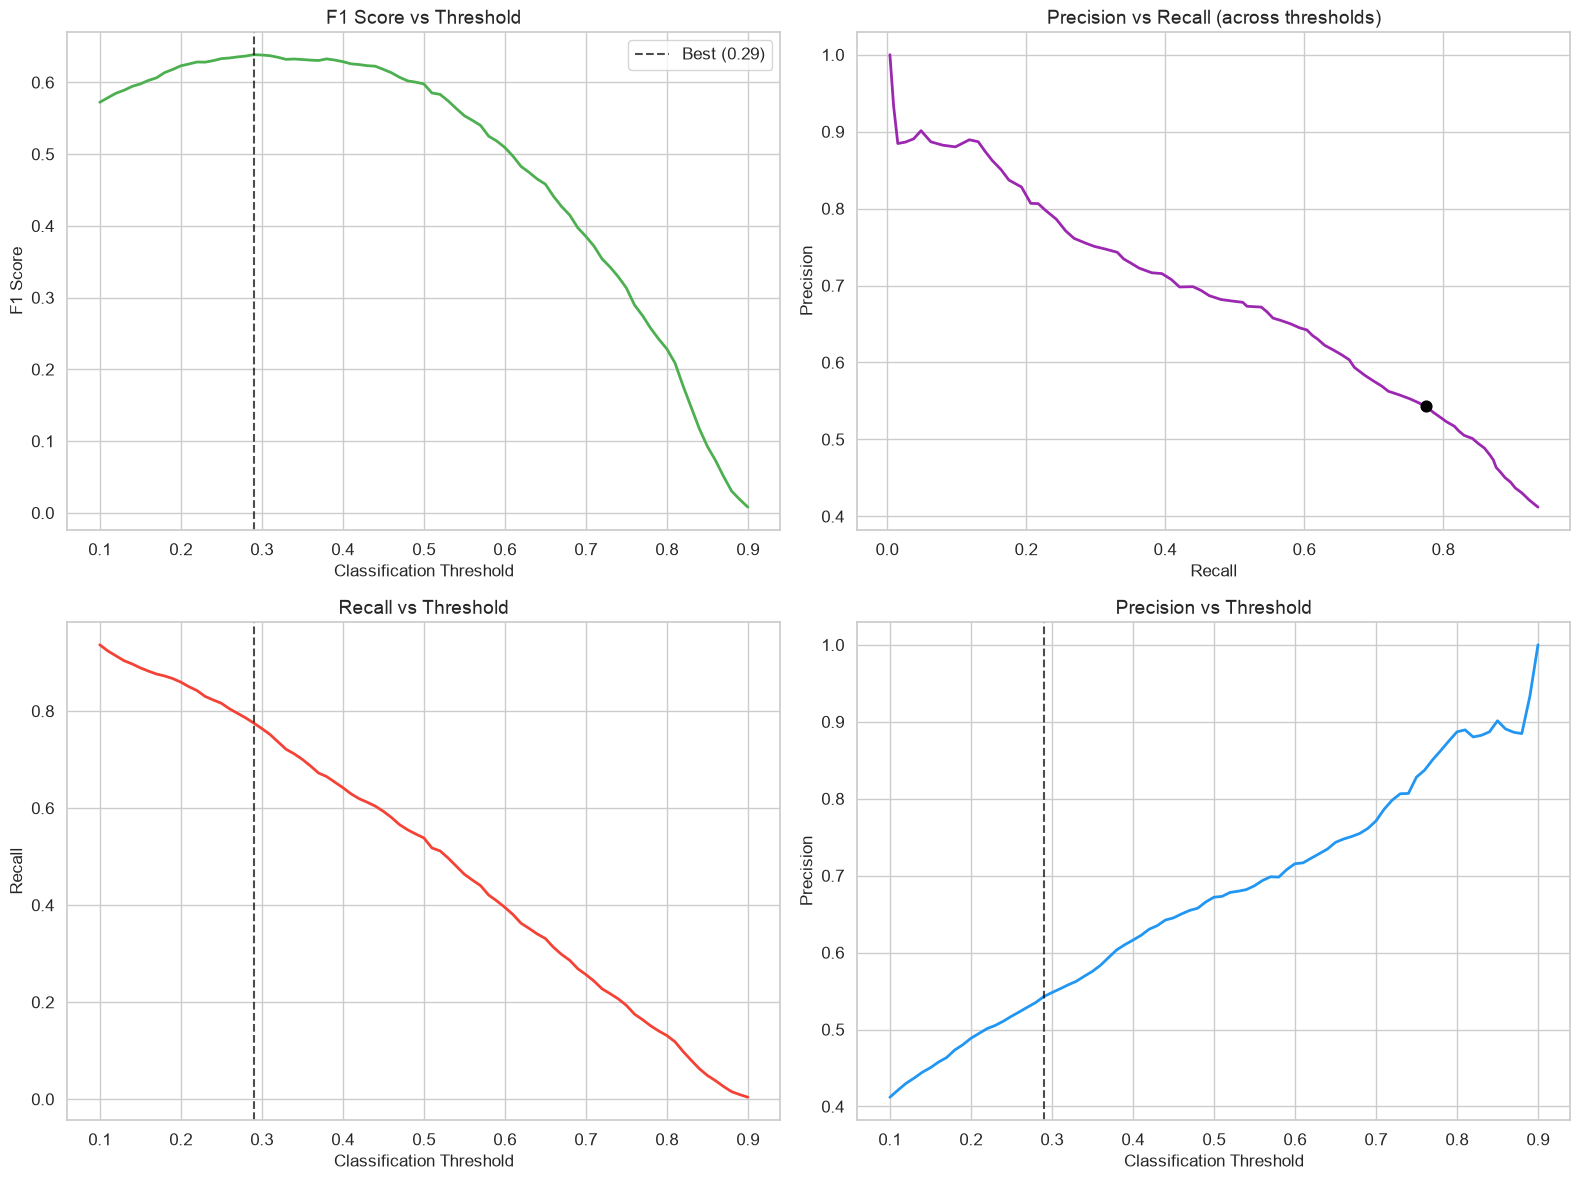

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. F1 vs Threshold
axes[0, 0].plot(threshold_results_v5["threshold"], threshold_results_v5["f1"], color="#4CAF50", lw=2)
axes[0, 0].axvline(best_threshold_v5, color="black", linestyle="--", alpha=0.7, label=f"Best ({best_threshold_v5})")
axes[0, 0].set_title("F1 Score vs Threshold")
axes[0, 0].set_xlabel("Classification Threshold")
axes[0, 0].set_ylabel("F1 Score")
axes[0, 0].legend()

# 2. Precision vs Recall
axes[0, 1].plot(threshold_results_v5["recall"], threshold_results_v5["precision"], color="#9C27B0", lw=2)
axes[0, 1].scatter(best_threshold_row["recall"], best_threshold_row["precision"], color="black", s=60, zorder=5)
axes[0, 1].set_title("Precision vs Recall (across thresholds)")
axes[0, 1].set_xlabel("Recall")
axes[0, 1].set_ylabel("Precision")

# 3. Recall vs Threshold
axes[1, 0].plot(threshold_results_v5["threshold"], threshold_results_v5["recall"], color="#F44336", lw=2)
axes[1, 0].axvline(best_threshold_v5, color="black", linestyle="--", alpha=0.7)
axes[1, 0].set_title("Recall vs Threshold")
axes[1, 0].set_xlabel("Classification Threshold")
axes[1, 0].set_ylabel("Recall")

# 4. Precision vs Threshold
axes[1, 1].plot(threshold_results_v5["threshold"], threshold_results_v5["precision"], color="#2196F3", lw=2)
axes[1, 1].axvline(best_threshold_v5, color="black", linestyle="--", alpha=0.7)
axes[1, 1].set_title("Precision vs Threshold")
axes[1, 1].set_xlabel("Classification Threshold")
axes[1, 1].set_ylabel("Precision")

plt.tight_layout()
plt.show()

---

## 7 · Final Test Evaluation

Now, and **ONLY now**, we evaluate the already-trained V4 tuned XGBoost model on the untouched test set (`X_test`/`y_test`) at the optimal threshold. We also evaluate at 0.50 to provide a direct comparison.

> **Important Note:** ROC-AUC measures ranking ability across *all* thresholds. It does not depend on a specific classification cutoff. Therefore, ROC-AUC is exactly the same for XGBoost at 0.50 and XGBoost at the optimized threshold.

In [9]:
# Get test set probabilities using V4 model
y_prob_test = model_v4_tuned.predict_proba(X_test)[:, 1]
auc_test = roc_auc_score(y_test, y_prob_test)

def evaluate_threshold(prob, y_true, threshold):
    y_pred = (prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": auc_test,  # Identical for any threshold
        "tp": int(tp), "tn": int(tn), "fp": int(fp), "fn": int(fn)
    }

metrics_050 = evaluate_threshold(y_prob_test, y_test, 0.50)
metrics_best = evaluate_threshold(y_prob_test, y_test, best_threshold_v5)

print("=" * 50)
print(f"  V5 (Tuned XGBoost) — Test Evaluation @ {best_threshold_v5:.2f}")
print("=" * 50)
print(f"  Accuracy  : {metrics_best['accuracy']:.4f}")
print(f"  Precision : {metrics_best['precision']:.4f}")
print(f"  Recall    : {metrics_best['recall']:.4f}")
print(f"  F1-score  : {metrics_best['f1']:.4f}")
print(f"  ROC-AUC   : {metrics_best['roc_auc']:.4f}")
print("=" * 50)

  V5 (Tuned XGBoost) — Test Evaluation @ 0.29
  Accuracy  : 0.7608
  Precision : 0.5336
  Recall    : 0.7861
  F1-score  : 0.6357
  ROC-AUC   : 0.8490


---

## 8 · V4 XGBoost @ 0.50 vs V5 XGBoost @ Optimized Threshold

In [10]:
comparison_v4_v5 = pd.DataFrame({
    "Metric": [
        "Accuracy", "Precision", "Recall", "F1", "ROC-AUC",
        "TP", "TN", "FP", "FN"
    ],
    "V4 XGBoost @ 0.50": [
        f"{metrics_050['accuracy']:.4f}", f"{metrics_050['precision']:.4f}",
        f"{metrics_050['recall']:.4f}", f"{metrics_050['f1']:.4f}",
        f"{metrics_050['roc_auc']:.4f}",
        metrics_050['tp'], metrics_050['tn'], metrics_050['fp'], metrics_050['fn']
    ],
    f"V5 XGBoost @ {best_threshold_v5}": [
        f"{metrics_best['accuracy']:.4f}", f"{metrics_best['precision']:.4f}",
        f"{metrics_best['recall']:.4f}", f"{metrics_best['f1']:.4f}",
        f"{metrics_best['roc_auc']:.4f}",
        metrics_best['tp'], metrics_best['tn'], metrics_best['fp'], metrics_best['fn']
    ]
})

deltas = [
    metrics_best['accuracy'] - metrics_050['accuracy'],
    metrics_best['precision'] - metrics_050['precision'],
    metrics_best['recall'] - metrics_050['recall'],
    metrics_best['f1'] - metrics_050['f1'],
    metrics_best['roc_auc'] - metrics_050['roc_auc'],
    metrics_best['tp'] - metrics_050['tp'],
    metrics_best['tn'] - metrics_050['tn'],
    metrics_best['fp'] - metrics_050['fp'],
    metrics_best['fn'] - metrics_050['fn']
]

comparison_v4_v5["Change"] = [
    f"{d:+.4f}" if isinstance(d, float) else f"{d:+d}" for d in deltas
]

print("Impact of Threshold Optimization on XGBoost")
print("=" * 75)
print(comparison_v4_v5.to_string(index=False))

Impact of Threshold Optimization on XGBoost
   Metric V4 XGBoost @ 0.50 V5 XGBoost @ 0.29  Change
 Accuracy            0.8055            0.7608 -0.0447
Precision            0.6724            0.5336 -0.1388
   Recall            0.5214            0.7861 +0.2647
       F1            0.5873            0.6357 +0.0483
  ROC-AUC            0.8490            0.8490 +0.0000
       TP               195               294     +99
       TN               940               778    -162
       FP                95               257    +162
       FN               179                80     -99


---

## 9 · Confusion Matrices & Business Interpretation

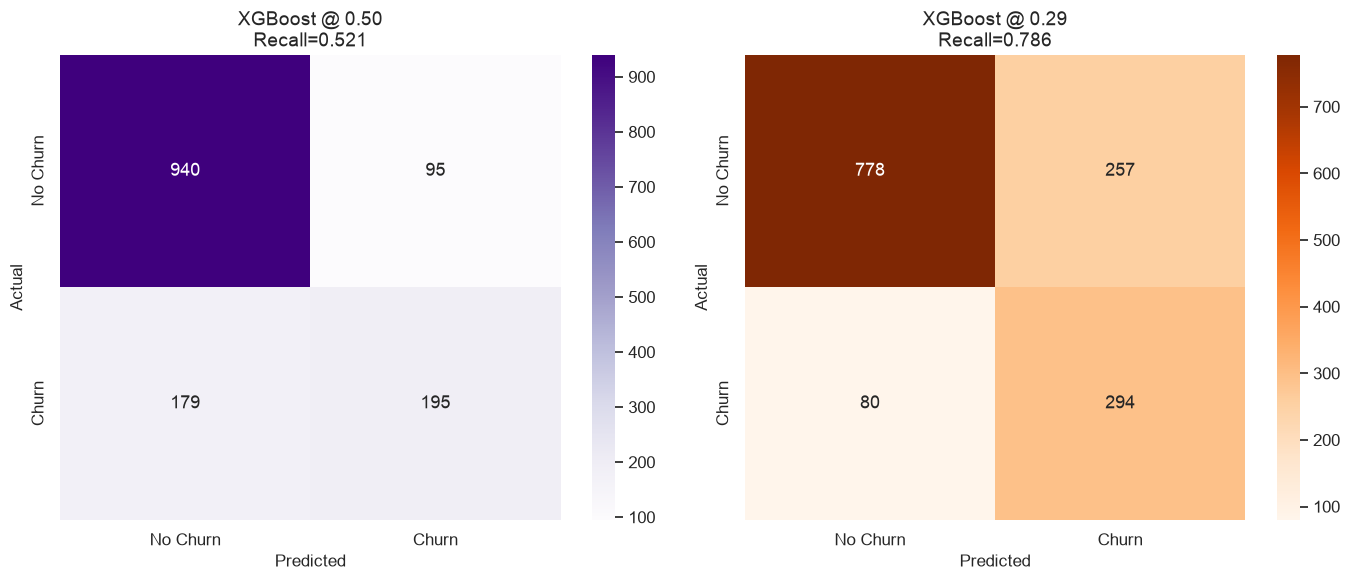

Confusion Matrix Impact:
  Caught churners (TP): 195 → 294 (Δ +99)
  Missed churners (FN): 179 → 80 (Δ -99)
  False alarms    (FP): 95 → 257 (Δ +162)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm_050 = np.array([[metrics_050["tn"], metrics_050["fp"]], [metrics_050["fn"], metrics_050["tp"]]])
cm_best = np.array([[metrics_best["tn"], metrics_best["fp"]], [metrics_best["fn"], metrics_best["tp"]]])

sns.heatmap(cm_050, annot=True, fmt="d", cmap="Purples", ax=axes[0],
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
axes[0].set_title(f"XGBoost @ 0.50\nRecall={metrics_050['recall']:.3f}")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

sns.heatmap(cm_best, annot=True, fmt="d", cmap="Oranges", ax=axes[1],
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
axes[1].set_title(f"XGBoost @ {best_threshold_v5}\nRecall={metrics_best['recall']:.3f}")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

print("Confusion Matrix Impact:")
print(f"  Caught churners (TP): {metrics_050['tp']} → {metrics_best['tp']} (Δ {metrics_best['tp'] - metrics_050['tp']:+d})")
print(f"  Missed churners (FN): {metrics_050['fn']} → {metrics_best['fn']} (Δ {metrics_best['fn'] - metrics_050['fn']:+d})")
print(f"  False alarms    (FP): {metrics_050['fp']} → {metrics_best['fp']} (Δ {metrics_best['fp'] - metrics_050['fp']:+d})")

### Business Interpretation

Lowering the threshold generally makes the model more willing to classify customers as churners. This naturally increases recall (fewer missed churners) but also increases false positives (more false alarms). Increasing the threshold makes the model more conservative.

Threshold selection represents a **business trade-off**, rather than just a mathematical optimization.

For IntelliPulse:
- If the business wants to identify as many potential churners as possible (because retention actions are cheap, e.g., an automated email), a lower threshold may be preferable.
- If retention campaigns are expensive (e.g., offering large discounts, account manager calls) and false positives are costly, a higher threshold may be preferable.

There is no universally "best" threshold—it depends entirely on the financial cost-benefit ratio of True Positives vs False Positives.

---

## 10 · Final Model Comparison

We compare all major models, separating the default threshold from the optimized ones.

In [12]:
final_table = pd.DataFrame({
    "Experiment": ["V1", "V3", "V3.1", "V4", "V2.1", "V5"],
    "Model": ["Logistic Regression", "Random Forest", "Tuned Random Forest", "Tuned XGBoost", "Logistic Regression", "Tuned XGBoost"],
    "Threshold": ["0.50", "0.50", "0.50", "0.50", f"0.27 (opt)", f"{best_threshold_v5} (opt)"],
    "Accuracy": [v1_metrics['accuracy'], v3_metrics['accuracy'], v3_1_metrics['accuracy'], v4_metrics['accuracy'], v2_1_metrics['accuracy'], metrics_best['accuracy']],
    "Precision": [v1_metrics['precision'], v3_metrics['precision'], v3_1_metrics['precision'], v4_metrics['precision'], v2_1_metrics['precision'], metrics_best['precision']],
    "Recall": [v1_metrics['recall'], v3_metrics['recall'], v3_1_metrics['recall'], v4_metrics['recall'], v2_1_metrics['recall'], metrics_best['recall']],
    "F1": [v1_metrics['f1_score'], v3_metrics['f1'], v3_1_metrics['f1'], v4_metrics['f1_score'], v2_1_metrics['f1'], metrics_best['f1']],
    "ROC-AUC": [v1_metrics['roc_auc'], v3_metrics['roc_auc'], v3_1_metrics['roc_auc'], v4_metrics['roc_auc'], v1_metrics['roc_auc'], metrics_best['roc_auc']],
})

print("Final Model Comparison (Default & Optimized Thresholds)")
print("=" * 110)
print(final_table.to_string(index=False))

Final Model Comparison (Default & Optimized Thresholds)
Experiment               Model  Threshold  Accuracy  Precision   Recall       F1  ROC-AUC
        V1 Logistic Regression       0.50  0.805500   0.657200 0.558800 0.604000 0.842100
        V3       Random Forest       0.50  0.777100   0.600700 0.478600 0.532700 0.820600
      V3.1 Tuned Random Forest       0.50  0.796309   0.639871 0.532086 0.581022 0.837270
        V4       Tuned XGBoost       0.50  0.805500   0.672400 0.521400 0.587300 0.849000
      V2.1 Logistic Regression 0.27 (opt)  0.746600   0.514900 0.783400 0.621400 0.842100
        V5       Tuned XGBoost 0.29 (opt)  0.760823   0.533575 0.786096 0.635676 0.849049


---

## 11 · Save Results

In [13]:
# Save threshold sweep results
csv_path = METRICS_DIR / "xgboost_v5_threshold_results.csv"
threshold_results_v5.to_csv(csv_path, index=False)
print(f"✓ V5 threshold results saved to: {csv_path}")

# Save JSON summary
v5_summary = {
    "experiment": "V5 — XGBoost Threshold Optimization",
    "best_threshold": float(best_threshold_v5),
    "validation_f1_at_best_threshold": float(val_f1_at_best),
    "test_metrics_at_0_50": {k: float(v) if isinstance(v, (int, float, np.integer, np.floating)) else v for k, v in metrics_050.items()},
    "test_metrics_at_best_threshold": {k: float(v) if isinstance(v, (int, float, np.integer, np.floating)) else v for k, v in metrics_best.items()}
}

json_path = METRICS_DIR / "xgboost_v5.json"
with open(json_path, "w") as f:
    json.dump(v5_summary, f, indent=2)
print(f"✓ V5 summary saved to: {json_path}")

✓ V5 threshold results saved to: /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/metrics/xgboost_v5_threshold_results.csv
✓ V5 summary saved to: /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/metrics/xgboost_v5.json


---

## 12 · V5 Findings

In [14]:
print("=" * 75)
print("  IntelliPulse V5 — XGBoost Threshold Optimization Findings")
print("=" * 75)
print()

print(f"1. What threshold maximized validation F1?       : {best_threshold_v5}")
print(f"2. What was validation F1 at that threshold?     : {val_f1_at_best:.4f}")
print(f"3. What was test F1 at threshold 0.50?           : {metrics_050['f1']:.4f}")
print(f"4. What was test F1 at the optimized threshold?  : {metrics_best['f1']:.4f}")
print(f"5. How did recall change?                        : {metrics_050['recall']:.4f} → {metrics_best['recall']:.4f} (Δ {metrics_best['recall'] - metrics_050['recall']:+.4f})")
print(f"6. How did precision change?                     : {metrics_050['precision']:.4f} → {metrics_best['precision']:.4f} (Δ {metrics_best['precision'] - metrics_050['precision']:+.4f})")
print(f"7. How did the confusion matrix change?          : Missed churners dropped by {metrics_050['fn'] - metrics_best['fn']}, but false alarms rose by {metrics_best['fp'] - metrics_050['fp']}.")
print(f"8. Did ROC-AUC change?                           : No, ROC-AUC remains {metrics_050['roc_auc']:.4f} because it is threshold-independent.")
print(f"9. Did threshold optimization improve F1?        : {'Yes' if metrics_best['f1'] > metrics_050['f1'] else 'No'} (Δ {metrics_best['f1'] - metrics_050['f1']:+.4f}).")
print()
print("10. What business trade-off does the selected threshold create?")
print("    Lowering the threshold captures more churners (higher recall), which saves")
print("    customer lifetime value. However, it increases false positives, meaning")
print("    retention spending will be wasted on some loyal customers. The selected")
print("    threshold is optimal *only* if the goal is strictly maximizing the mathematical")
print("    F1 score. In reality, the business must dictate the optimal threshold")
print("    based on actual retention costs vs saved revenue.")
print("=" * 75)
print("\nNote: V4 and previous experiments remain untouched.")

  IntelliPulse V5 — XGBoost Threshold Optimization Findings

1. What threshold maximized validation F1?       : 0.29
2. What was validation F1 at that threshold?     : 0.6386
3. What was test F1 at threshold 0.50?           : 0.5873
4. What was test F1 at the optimized threshold?  : 0.6357
5. How did recall change?                        : 0.5214 → 0.7861 (Δ +0.2647)
6. How did precision change?                     : 0.6724 → 0.5336 (Δ -0.1388)
7. How did the confusion matrix change?          : Missed churners dropped by 99, but false alarms rose by 162.
8. Did ROC-AUC change?                           : No, ROC-AUC remains 0.8490 because it is threshold-independent.
9. Did threshold optimization improve F1?        : Yes (Δ +0.0483).

10. What business trade-off does the selected threshold create?
    Lowering the threshold captures more churners (higher recall), which saves
    customer lifetime value. However, it increases false positives, meaning
    retention spending will be waste